# Coursework Set Week 7

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Lucie Klingens
* Username: lklingens
* Student number: s6390366
* Group (AS1, etc.): AS6

-----

In [1]:
totalpoints = currentpoints = 0

### Simpson's rule (4 pt)  <font color='red'><b>COURSEWORK</b></font>

In section 'Simpson's rule' in the task documentation we plotted the function $f(x) = 1 + x + \sin(2x)$

* Create a object-oriented code that the input variables are a function you wish to integral in string and the integral intervals, `a` and `b`.
* Add a function in the object that calculates the integration with the Trapezium rule.
* Add a function in the object that calculates the integration with the Simpson’s rule.
* Add a function in the object that calculates the integration with Monte Carlo integration.
* Add a function in the object that calculates the integration with SymPy (``sympy.integrate()``).
* Add a function in the object that calculates the integration with SciPy (``quad()`` function).
* Use ``a=0.5`` and ``b=3.0`` as the test using all methods you create in the object. Print the test.
  
**Answers**:  

In [2]:
import numpy as np
from sympy import integrate, symbols
from scipy.integrate import quad
from numexpr import evaluate

class integration:
    """A class that contains methods to integrate over a and b when a function is entered """
    def __init__(self, a, b, n, function):
        self.x = np.linspace(a, b, n)  # Create x-values within the interval [a,b].
        self.a = a
        self.b = b
        self.n = n
        self.function = function  # The function has to be entered as a string here.
        self.f = lambda x: evaluate(self.function)  # Evaluate the given function for x (to bypass the eval() disadvantages).
    def Trapezium(self):
        """A function in the object that calculates the integration with the Trapezium rule"""
        f_a = self.f(self.a)
        f_b = self.f(self.b)
        trap_area = (self.b-self.a)*((f_a+f_b)/2)
        return trap_area
    def Simpson(self):
        """A function in the object that calculates the integration with the Simpson’s rule"""
        h = (self.b-self.a)/self.n
        f_first = self.f(self.x[0])  # First y-value
        f_last = self.f(self.x[-1])  # Last y-value
        if len(self.x) % 2 == 0:  # If the amount of numbers in x is even (first is 0, last is uneven number)
            f_4 = 4 * self.f(self.x[2:-1:2]).sum()
            f_2 = 2 * self.f(self.x[1:-2:2]).sum()
        else:
            f_4 = 4 * self.f(self.x[2::2]).sum()
            f_2 = 2 * self.f(self.x[1:-1:2]).sum()
        simp_int = ((h)/3)*(f_first+f_4+f_2+f_last)
        return simp_int
    def Montecarlo(self):
        """A function in the object that calculates the integration with Monte Carlo integration"""
        h = (self.b-self.a)/self.n
        sums = self.f(self.x).sum()
        mc_int = (h)*sums
        return mc_int
    def Sympy(self):
        """A function in the object that calculates the integration with SymPy"""
        x = symbols('x')  # Define the symbol x, the variable in a function, as sympy.integrate does not take the array of x-values as an argument.
        sp_int = integrate(self.function, (x, self.a, self.b))
        return sp_int
    def Scipy(self):
        """A function in the object that calculates the integration with SciPy"""
        sci_int, error = quad(self.f, self.a, self.b)
        return sci_int

# Create instances
integral = integration(0.5, 3.0, 100, '1 + x + sin(2*x)')
int_trap = integral.Trapezium()
int_simp = integral.Simpson()
int_mc = integral.Montecarlo()
int_sp = integral.Sympy()
int_sci = integral.Scipy()

# Print the outputs
print(f"The result of the integration with a = 0.5 and b = 3.0 for f(x) = 1 + x + sin(2x):"
      f"\nWith the Trapezium rule: {int_trap}"
      f"\nWith the Simpson rule: {int_simp}"
      f"\nWith Monte Carlo integration: {int_mc}"
      f"\nWith SymPy integration: {int_sp}"
      f"\nWith SciPy integration: {int_sci}")

The result of the integration with a = 0.5 and b = 3.0 for f(x) = 1 + x + sin(2x):
With the Trapezium rule: 7.577569358261213
With the Simpson rule: 6.578684140781255
With Monte Carlo integration: 6.674235223001931
With SymPy integration: 6.66506600960889
With SciPy integration: 6.6650660096088865


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Fitting a Gaussian model for velocity profile data (16 pt) <font color='red'><b>COURSEWORK</b></font>

For this assignment we use the HI radio FITS cube
[ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)

It contains 101 channel maps with radio interferometer HI data.

1. (3 pt) A global HI profile is a set of measurements at fixed R.A. and Dec. as function of the spectral 
   axis (frequency or velocity). It shows at which frequency (or velocity) there is a peak in HI.
   Plot this profile for R.A. (x) index 58 and Dec. (y) index 55. 
   Label the X axis with the header value ``CUNIT3`` and the Y axis with the intensity 
   units in ``BUNIT``. For this data, the pixels represent brightness.
   
   In the global profile, the first pixel corresponds to 233 km/s and the last pixel corresponds to 377 km/s.
   Convert your X axis from pixel index numbers to km/s (use NumPy's ``linspace()`` to define the X values).
   
**Answer**:

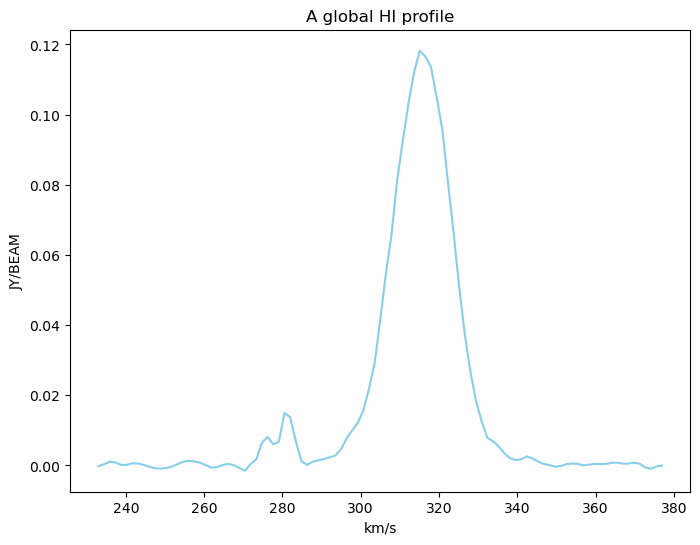

In [4]:
from astropy.io import fits
from matplotlib.pyplot import figure, show
import numpy as np

hdulist = fits.open('/Users/users/lklingens/PROGNUM-repo/Task7/ngc6946.fits')  # Open the file.
hdr = hdulist[0].header  # Get first row of information, which is the header.
data = hdulist[0].data  # Get the image data from the primary header.

# Slice data for RA = index 58 and DEC = index 55
data_slice = data[:,55,58] 

# Velocities pixel values for all channel maps
X = np.linspace(233, 377, 101)

fig = figure(figsize=(8,6))
frame = fig.add_subplot(1,1,1)
frame.plot(X, data_slice, color='skyblue')
frame.set_title("A global HI profile")
frame.set_xlabel(f"{hdr['CUNIT3']}")
frame.set_ylabel(f"{hdr['BUNIT']}")

show()

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

2. (1 pt) Assume the profile can be modeled by a Gaussian. Make a function with signature:

          def f(x, amp, mu, sigma, zero):

   which returns the value of a Gaussian function with amplitude ``amp`` centered at
   position ``mu`` with width ``sigma`` and offset with respect to the x axis of ``zero``
   
**Answer**:   

In [6]:
import numpy as np

def f(x, amp, mu, sigma, zero):
    return amp*np.exp(-((x-mu)**2)/(2*sigma**2))+zero  # Gaussian function

In [7]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Remember how to distinguish linear- from non-linear models. Always look at the derivatives to the parameters.

3. (1 pt) Give a simple proof that this function ``f`` represents a non-linear model

**Answer**:

For linear Least Squares problems (LLS) the first derivative of the model with respect to any parameters is zero or depends only on the independent variable, usually. If this is not true then the problem is a so-called Non-Linear Least Squares problem (NLLS).

The Gaussian function:
$$f = A e^{-\frac{(x-\mu)^2}{2\sigma^2}} + z_0$$
where A is the amplitude and $z_0$ the offset with respect to the x-axis.

We can always use Sympy’s $'diff'$ to symbolically differentiate an expression to derive whether the model is linear or non-linear.

In [8]:
import sympy as sp

x, amp, mu, sigma, zero = sp.symbols('x amp mu sigma zero')
Gauss = amp*sp.exp(-((x-mu)**2)/(2*sigma**2))+zero

print(f"Before differentiation, the function is: {Gauss}")

# Use sympy.diff() method for all parameters to check if derivative contains parameter.
diff_amp = sp.diff(Gauss, amp)
diff_mu = sp.diff(Gauss, mu)
diff_sig = sp.diff(Gauss, sigma)
diff_zero = sp.diff(Gauss, zero)

print(f"\nAfter differentiation for each parameter, the function is:"
        f"\nDifferenting w.r.t amp: {diff_amp}"
        f"\nDifferentiating w.r.t mu: {diff_mu}"
        f"\nDifferentiating w.r.t sigma: {diff_sig}"
        f"\nDifferentiating w.r.t zero: {diff_zero}")
print("\nTwo out of four derivatives still depend on the parameters they were differentiated for, so the Gaussian function f is a non-linear model.")

Before differentiation, the function is: amp*exp(-(-mu + x)**2/(2*sigma**2)) + zero

After differentiation for each parameter, the function is:
Differenting w.r.t amp: exp(-(-mu + x)**2/(2*sigma**2))
Differentiating w.r.t mu: -amp*(2*mu - 2*x)*exp(-(-mu + x)**2/(2*sigma**2))/(2*sigma**2)
Differentiating w.r.t sigma: amp*(-mu + x)**2*exp(-(-mu + x)**2/(2*sigma**2))/sigma**3
Differentiating w.r.t zero: 1

Two out of four derivatives still depend on the parameters they were differentiated for, so the Gaussian function f is a non-linear model.


In [9]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Initial estimates are essential for a good fit. If they are not close enough to the real values, you can find a fit but without a guarantee that it is the best fit.

4. (3 pt) For a least squares fit with function `scipy.optimize.curve_fit()` we need reasonable initial estimates. Find reasonable estimates and motivate why you think they are reasonable and then use them as argument ``p0`` in ``curve_fit()`` to find the best fit model parameters and their (scaled) standard errors    

**Answer**:

In [10]:
from scipy.optimize import curve_fit
import numpy as np

"""They parameters are called as followed:
beta0 = amp
beta1 = mu
beta2 = sigma
beta3 = zero"""

def model(x, beta0, beta1, beta2, beta3):
    y = beta0*np.exp(-((x-beta1)**2)/(2*beta2**2))+beta3  # Gaussian function
    return y

X = np.linspace(233, 377, 101)  # Velocity pixel values from 1.
data_slice = data[:,55,58]  # Intensity values from 1.

# Initial guesses
beta0 = np.max(data_slice)  # Estimate of the amplitude.
beta1 = X[np.argmax(data_slice)]  # Estimate of mu (the velocity where the intensity is the highest).
beta2 = 10  # Estimate of sigma: 10 km/s width.
beta3 = np.min(data_slice)  # Estimate of offset.

p0 = [beta0, beta1, beta2, beta3]

beta, pcov = curve_fit(model, X, data_slice, p0=p0)
err = np.sqrt(np.diag(pcov))  # To get the standard deviation from pcov (variance).

# Print the best fit model parameters with their errors, formatted to 6 floating points.
print(f"Best fit model parameter of the amplitude: {beta[0]:.6f} +/- {err[0]:.6f}")
print(f"Best fit model parameter of the mean (mu): {beta[1]:.6f} +/- {err[1]:.6f} km/s")
print(f"Best fit model parameter of the width (sigma): {beta[2]:.6f} +/- {err[2]:.6f} km/s")
print(f"Best fit model parameter of the offset (zero): {beta[3]:.6f} +/- {err[3]:.6f}")

Best fit model parameter of the amplitude: 0.116939 +/- 0.001098
Best fit model parameter of the mean (mu): 315.716848 +/- 0.077180 km/s
Best fit model parameter of the width (sigma): 7.261066 +/- 0.081697 km/s
Best fit model parameter of the offset (zero): 0.001344 +/- 0.000305


Why the chosen estimates are resonable (based on the graph drawn in 1.):
* The amplitude is the height of the graph. So the height the intensity goes would be the amplitude. This means that taking the maximum of the y-values, the maximum of the data_slice, would be a good way to approach this.
* The mean is the central value of the graph. This is around the peak. The best way to approach that would be to find the X-value for which the insensity is at its maximum.
* Galaxies typically have a velocity dispersion in this range, which is why 10 km/s is a good approximation for sigma.
* The minimum value of the intensities best represents the noise level as it takes the background of the data into account.

In [11]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

5. (1 pt) Plot the model curve with its best fit parameter together with the data points    

**Answer**:

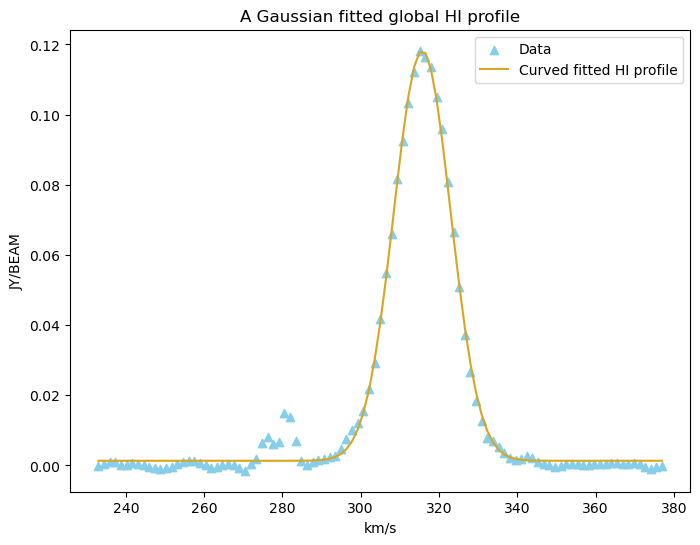

In [12]:
from matplotlib.pyplot import figure, show

fig = figure(figsize=(8,6))
frame = fig.add_subplot(1,1,1)

frame.scatter(X, data_slice, marker='^', color='skyblue', label='Data')  # Plot the data.

frame.plot(X, model(X, beta[0], beta[1], beta[2], beta[3]), color='goldenrod', label='Curved fitted HI profile')  # Plot the curve fitted model.

frame.set_title("A Gaussian fitted global HI profile")
frame.set_xlabel(f"{hdr['CUNIT3']}")
frame.set_ylabel(f"{hdr['BUNIT']}")
frame.legend()
show()

In [13]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Fitting multiple signals with a Gaussian.

6. (3 pt) If you fit is alright, you see that a small signal at the left of the main signal in your
   profile has not been fitted. You can add a second Gaussian (without a zero level because you 
   already have one offset) to model that second signal.
   Find the best fit parameter of this composed model and plot original data with the best fit curve 
   
**Answer**:

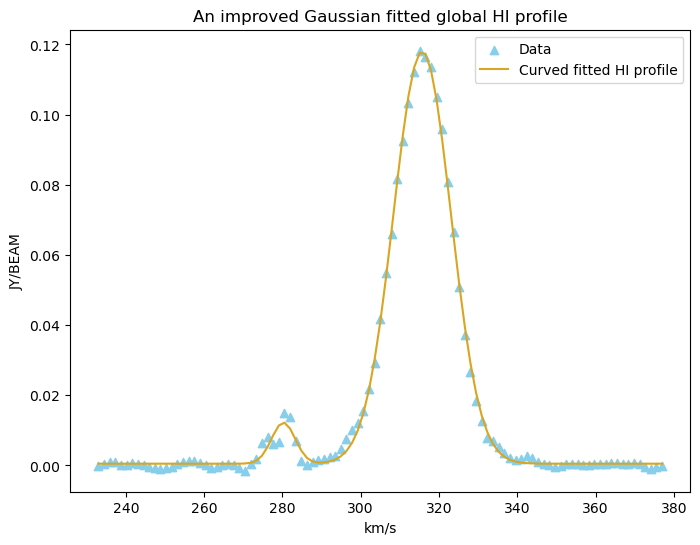

In [14]:
from matplotlib.pyplot import figure, show
from scipy.optimize import curve_fit
import numpy as np

def model_double(x, beta0, beta1, beta2, beta3, beta01, beta11, beta21):
    y = beta0*np.exp(-((x-beta1)**2)/(2*beta2**2))+beta3 + beta01*np.exp(-((x-beta11)**2)/(2*beta21**2))   # Gaussian function for the small signal
    return y

condition = np.where(X > 280)  # To find the second peak, 280 km/s is guessed by eye as a value that the peak is above. Returns tuple.

# Initial guesses
beta0 = np.max(data_slice)  # Estimate of the amplitude.
beta1 = X[np.argmax(data_slice)]  # Estimate of mu (the velocity where the intensity is the highest).
beta2 = 10  # Estimate of sigma: 10 km/s width.
beta3 = np.min(data_slice)  # Estimate of offset.
beta01 = data_slice[condition[0][0]]  # Estimate of the amplitude (peak) from the figure. Condition has to be indexed twice to get a value.
beta11 = X[condition[0][0]]  # Estimate of mu: the velocity where the intensity is the highest (= the peak).
beta21 = 10  # Estimate of sigma.

p0_double = [beta0, beta1, beta2, beta3, beta01, beta11, beta21]

beta_double, pcov_double = curve_fit(model_double, X, data_slice, p0=p0_double)
err_double = np.sqrt(np.diag(pcov_double))  # To get the standard deviation from pcov (variance).

fig2 = figure(figsize=(8,6))
frame2 = fig2.add_subplot(1,1,1)

frame2.scatter(X, data_slice, marker='^', color='skyblue', label='Data')  # Plot the data.

frame2.plot(X, model_double(X, *beta_double), color='goldenrod', label='Curved fitted HI profile')  # Plot the curve fitted model. *beta_double makes sure all beta_double values are used.

frame2.set_title("An improved Gaussian fitted global HI profile")
frame2.set_xlabel(f"{hdr['CUNIT3']}")
frame2.set_ylabel(f"{hdr['BUNIT']}")
frame2.legend()
show()

In [15]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

An important characterization of a peak is its width. In astronomy we use the FWHM.

7. (2 pt) What is the FWHM of the gas in the main peak and in the secondary peak. Also give the standard errors 
   in the FWHM. Do not forget to print the units
   
**Answer**:

In [16]:
import numpy as np

# The FWHM is calculated using the known formula and its erro is calculated 
# FWHM of the highest peak
FWHM_1 = 2*beta_double[2]*np.sqrt(2*np.log(2))  
sig1_err = np.sqrt(err_double[2])
se_1 = 2*sig1_err*np.sqrt(2*np.log(2))

# FWHM of the lower peak
FWHM_2 = 2*beta_double[-1]*np.sqrt(2*np.log(2))  
sig2_err = np.sqrt(err_double[-1])
se_2 = 2*sig2_err*np.sqrt(2*np.log(2))

# Print the FWHM's with their errors, formatted to 6 floating points.
print(f"FWHM of the highest peak: {FWHM_1:.6f} +/- {se_1:.6f} km/s")
print(f"FWHM of the lower peak: {FWHM_2:.6f} +/- {se_2:.6f} km/s")

FWHM of the highest peak: 17.271776 +/- 0.510008 km/s
FWHM of the lower peak: 7.115487 +/- 1.269074 km/s


In [17]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

8. (2 pt) Plot the FWHM's in the previous plot as horizontal lines at the positions of the fitted peak centers.
   Make the plot complete with labels, title and useful legend



**Answer**:

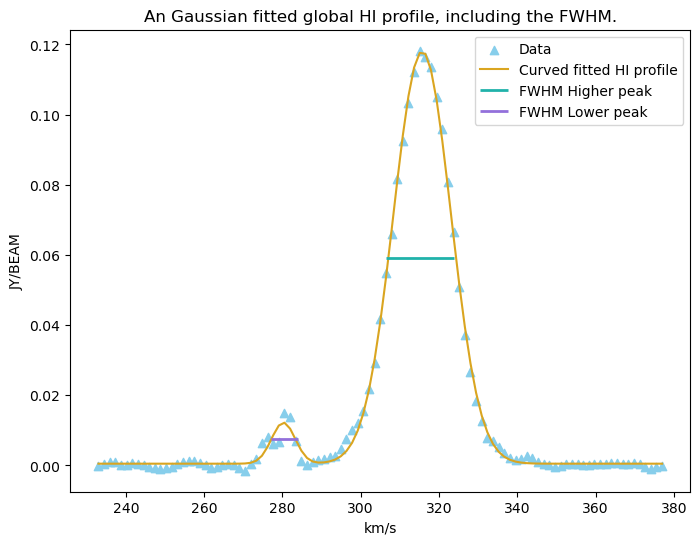

In [18]:
from matplotlib.pyplot import figure, show
from scipy.optimize import curve_fit
import numpy as np

def model_double(x, beta0, beta1, beta2, beta3, beta01, beta11, beta21):
    y = beta0*np.exp(-((x-beta1)**2)/(2*beta2**2))+beta3 + beta01*np.exp(-((x-beta11)**2)/(2*beta21**2))   # Gaussian function for the small signal
    return y

condition = np.where(X > 280)  # To find the second peak, 280 km/s is guessed by eye as a value that the peak is above. Returns tuple.

# Initial guesses
beta0 = np.max(data_slice)  # Estimate of the amplitude.
beta1 = X[np.argmax(data_slice)]  # Estimate of mu (the velocity where the intensity is the highest).
beta2 = 10  # Estimate of sigma: 10 km/s width.
beta3 = np.min(data_slice)  # Estimate of offset.
beta01 = data_slice[condition[0][0]]  # Estimate of the amplitude (peak) from the figure. Condition has to be indexed twice to get a value.
beta11 = X[condition[0][0]]  # Estimate of mu: the velocity where the intensity is the highest (= the peak).
beta21 = 10  # Estimate of sigma.

p0_double = [beta0, beta1, beta2, beta3, beta01, beta11, beta21]

beta_double, pcov_double = curve_fit(model_double, X, data_slice, p0=p0_double)
err_double = np.sqrt(np.diag(pcov_double))  # To get the standard deviation from pcov (variance).

fig3 = figure(figsize=(8,6))
frame3 = fig3.add_subplot(1,1,1)

frame3.scatter(X, data_slice, marker='^', color='skyblue', label='Data')  # Plot the data.
frame3.plot(X, model_double(X, *beta_double), color='goldenrod', label='Curved fitted HI profile')  # Plot the curve fitted model. *beta_double makes sure all beta_double values are used.

# Plot the FWHM's.
frame3.hlines(y=beta0/2, xmin=beta1-(FWHM_1/2), xmax=beta1 + (FWHM_1/2), color='lightseagreen', linewidth=2, label='FWHM Higher peak')
frame3.hlines(y=beta01/2, xmin=beta11 - (FWHM_2/2), xmax=beta11 + (FWHM_2/2), color='mediumpurple', linewidth=2, label='FWHM Lower peak')

frame3.set_title("An Gaussian fitted global HI profile, including the FWHM.")
frame3.set_xlabel(f"{hdr['CUNIT3']}")
frame3.set_ylabel(f"{hdr['BUNIT']}")
frame3.legend()
show()

In [19]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

### Smoothing a noisy image (5pt) <font color='red'><b>COURSEWORK</b></font>

Given is a noisy image of a galaxy in FITS file
[faintgalaxy.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/faintgalaxy.fits).
 
To improve the signal to noise ratio in this image, one can smooth the data with a simple algorithm.
    
1. Write a function ``smooth()`` with the following properties:

   * It has an argument ``M`` which is a 2D input image.
   * It returns an output image ``Mc`` with the same shape as the input image.
   * The input and output images do not share memory.
   * Each pixel at location ``(i,j)`` in the output image is the **mean** of 9 input pixels located at:
            
   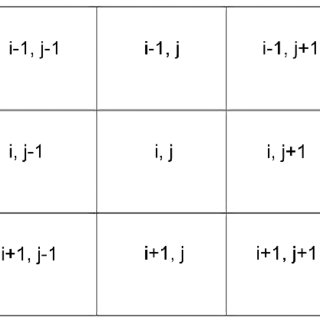    
       
   * Border pixels can be ignored and set to 0.0.
   * Interpolation is not needed.

<br>

2. Create a mosaic with two plots. One shows an image of the original data and the other shows the smoothed version. 
3. Use the function ``smooth2()`` below to smooth ``M`` with a SciPy routine and plot the result.
   
```python
    def smooth2(M):
        Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
        return Mc
```
    
**Strategy**

* The function should leave the original image unaltered, that is, we need to create a copy using one of:

     1. method ``copy()`` 
     1. ``np.zeros()`` 
     1. ``np.zeros_like()`` <br>&nbsp;<br>
   
* For each position (x, y) in the output image, we need to set some value except for the borders:

```python
    for y in range(1, ny-1):
        for x in range(1, nx-1):
```

* Or one uses function numpy.ndindex() and skips the index that represents a border pixel (gives faster code).
* The value of the pixel becomes the average of 9 neighbours in the input. We should then extract a sub-image 
  of 3x3 pixels centered at ``(x,y)``.
* For a 2dim structure ``M``, the pixel at ``(x,y)`` is given by ``M[y,x]``.
* The indices in ``M`` can be a range. To include the left and right, upper and lower neighbours of ``x``,
  we would write ``M[x-1:x+2, y-1:y+2]``.

**Answers**:

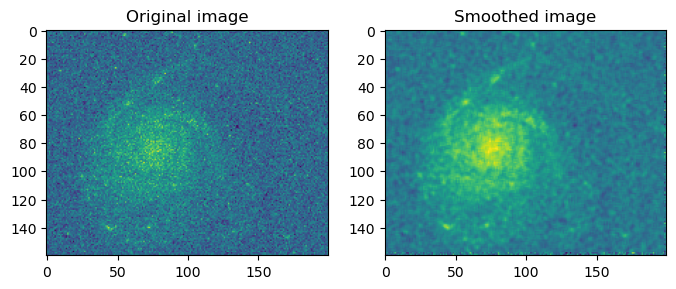

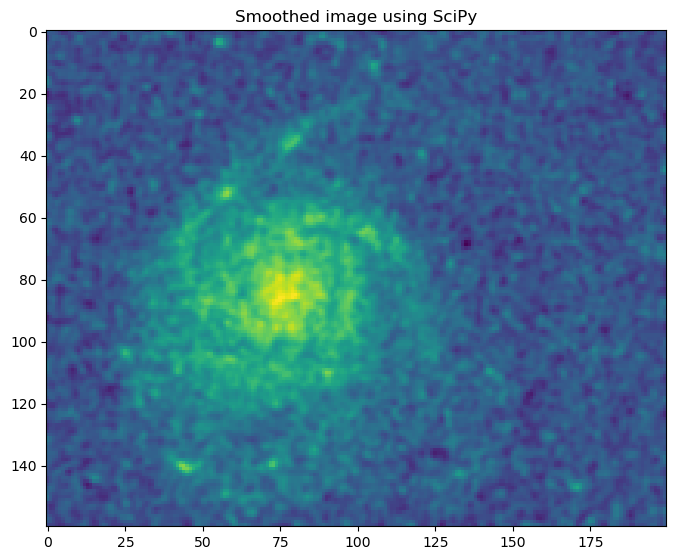

In [20]:
from astropy.io import fits
from matplotlib.pyplot import figure, show
import numpy as np
from scipy import ndimage

hdulist = fits.open('/Users/users/lklingens/PROGNUM-repo/Task7/faintgalaxy.fits')  # Open the file.
hdr = hdulist[0].header  # Get first row of information, which is the header.
data = hdulist[0].data  # Get the image data from the primary header.

def smooth(M):
    """A function that smoothes the input image, without sharing memory"""
    Mc = data.copy()
    row, col = Mc.shape  # Gives shape as a tuple: (x,y) = ...
    for y in range(1, row-1):
        for x in range(1, col-1):
            numbers = M[y-1:y+2,x-1:x+2]  # Get the values at the indices around (x,y).
            Mc[y-1,x-1] = np.mean(numbers)  # Calculate the mean of the 3x3 pixels and assign to the correct pixel in the output image.
    return Mc

# Make a figure and plot the original image.
fig = figure(figsize=(8,8))
frame = fig.add_subplot(1,2,1)
frame.imshow(data)
frame.set_title("Original image")

# Plot the smoothened image.
frame2 = fig.add_subplot(1,2,2)
frame2.imshow(smooth(data))
frame2.set_title("Smoothed image")

def smooth2(M):
    """A function that smoothens an imgae using SciPy"""
    Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
    return Mc

# Plot the smoothened SciPy image.
fig2 = figure(figsize=(8,8))
frame3 = fig2.add_subplot(1,1,1)
frame3.imshow(smooth2(data))
frame3.set_title("Smoothed image using SciPy")

show()

In [21]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [22]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 25. Student score: 0.0.  Task Grade = 0.0
